In [103]:
# Importación de librerías necesarias para el trabajo.
import pandas as pd               # Manejo de datos tabulares y series temporales
import numpy as np                # Operaciones numéricas y funciones matemáticas
import matplotlib.pyplot as plt   # Generación de gráficos
import warnings

from pathlib import Path          # Manejo de rutas relativas de archivos
# Importar la advertencia específica de statsmodels
from statsmodels.tools.sm_exceptions import InterpolationWarning

# Suprimir solo la advertencia de interpolación
warnings.filterwarnings("ignore", category=InterpolationWarning)

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf  # Pruebas de raíz unitaria y autocorrelaciones
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # Gráficos de ACF y PACF
from statsmodels.tsa.arima.model import ARIMA                  # Estimación de modelos ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox        # Prueba de Ljung-Box para ruido blanco

from scipy.signal import find_peaks  # Detección de picos en series temporales

In [104]:
# Definir rutas principales del proyecto
BASE_DIR = Path.cwd().parents[0]

DATA_RAW = BASE_DIR / "data" / "raw"
OUTPUT_FIGURES = BASE_DIR / "outputs" / "figures"
OUTPUT_TABLES = BASE_DIR / "outputs" / "tables"

# Crear carpetas de outputs si no existen
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

# Cargar base de datos
archivo = DATA_RAW / "datos_poster.xlsx"

df = pd.read_excel(archivo, sheet_name="Datos")

In [105]:
# Se revisa la columna de fechas para identificar su formato actual (string o datetime) y poder convertirla correctamente más adelante.
print("Primeras 10 filas de la columna 'Mes':")
print(df['Mes'].head(10))
print("\nTipo de datos:", df['Mes'].dtype)

Primeras 10 filas de la columna 'Mes':
0    2003-ene
1    2003-feb
2    2003-mar
3    2003-abr
4    2003-may
5    2003-jun
6    2003-jul
7    2003-ago
8    2003-sep
9    2003-oct
Name: Mes, dtype: object

Tipo de datos: object


La columna `Mes` se lee como tipo `str` (cadena de texto) con abreviaturas de meses en español (`ene`, `feb`, `mar`, ...). Esto impide que pandas reconozca automáticamente la columna como una fecha, y por lo tanto no se puede utilizar directamente como índice temporal ni para operaciones de rezago o diferenciación. Para poder trabajar con series de tiempo, es necesario **convertir estas cadenas a objetos `datetime`**. La conversión debe considerar que el formato `%Y-%b` (año-mes abreviado) espera meses en inglés, por lo que previamente se debe reemplazar cada abreviatura española por su equivalente en inglés. Una vez convertido, podremos establecer `Mes` como índice y definir la frecuencia mensual (`MS`), lo que habilitará todas las funcionalidades de análisis temporal de `statsmodels`.

In [106]:
# Se convierte la columna 'Mes' de string a datetime para usarla como índice temporal.
# Como los meses están en español, se mapean a inglés antes de la conversión, pues pd.to_datetime() con formato '%Y-%b' espera meses en inglés.

# Diccionario de traducción de abreviaturas de meses (español -> inglés)
meses = {'ene':'Jan','feb':'Feb','mar':'Mar','abr':'Apr','may':'May','jun':'Jun',
         'jul':'Jul','ago':'Aug','sep':'Sep','oct':'Oct','nov':'Nov','dic':'Dec'}

In [107]:
# La siguiente línea reemplaza abreviaturas de meses en español por sus equivalentes en inglés
# dentro de la columna 'Mes', usando expresiones regulares (regex).

# r'...' indica una cadena "raw", lo que permite escribir la regex sin duplicar barras invertidas.

# El patrón:
# -(ene|feb|mar|abr|may|jun|jul|ago|sep|oct|nov|dic)
# busca un guión seguido de cualquiera de las abreviaturas de meses en español.
#
# Los paréntesis crean un grupo de captura. Luego, x.group(1) recupera únicamente
# la abreviatura encontrada (por ejemplo: "ene" o "feb").

# lambda x: función que se ejecuta sobre cada coincidencia encontrada.
#
# meses[x.group(1)] busca en el diccionario 'meses' el equivalente en inglés
# de la abreviatura capturada.
#
# El reemplazo final conserva el guión y cambia únicamente el mes:
# por ejemplo, "-ene" se convierte en "-jan".

# regex=True indica que el patrón debe interpretarse como una expresión regular
# y no como texto literal.

df['Mes'] = df['Mes'].str.replace(
    r'-(ene|feb|mar|abr|may|jun|jul|ago|sep|oct|nov|dic)',
    lambda x: '-' + meses[x.group(1)],
    regex=True
)

In [108]:

# Convierte la cadena con formato 'año-mes' (ej. '2003-Jan') a tipo datetime
df['Mes'] = pd.to_datetime(df['Mes'], format='%Y-%b')

# Establece la columna 'Mes' como índice del DataFrame.
# inplace=True indica que el cambio se aplica directamente sobre el DataFrame original,
# sin necesidad de crear una copia ni reasignar el resultado a la variable 'df'.
# Sin inplace=True, habría que escribir:
# df = df.set_index('Mes')

df.set_index('Mes', inplace=True)

# Fuerza la frecuencia a 'MS' (Monthly Start, inicio de mes) para operaciones temporales
df = df.asfreq('MS')

# Verifica las primeras 5 fechas del índice
print(df.index[:5])

DatetimeIndex(['2003-01-01', '2003-02-01', '2003-03-01', '2003-04-01',
               '2003-05-01'],
              dtype='datetime64[ns]', name='Mes', freq='MS')


In [109]:
# Extraer la serie de CDS del DataFrame y eliminar valores nulos (si los hay)
# CDS representa el riesgo país de Colombia (Credit Default Swap)
cds = df['CDS'].dropna()

# Mostrar información básica: número de observaciones y periodo cubierto
print(f"Número de observaciones: {len(cds)}")
print(f"Periodo: desde {cds.index[0]} hasta {cds.index[-1]}")

# Calcular y mostrar estadísticas descriptivas para entender distribución
print("\nEstadísticas descriptivas de CDS:")
print(cds.describe())

Número de observaciones: 269
Periodo: desde 2003-01-01 00:00:00 hasta 2025-05-01 00:00:00

Estadísticas descriptivas de CDS:
count    269.000000
mean     197.294589
std      124.702109
min       73.931391
25%      118.371333
50%      153.643043
75%      223.120773
max      825.312500
Name: CDS, dtype: float64


La serie de CDS cuenta con 269 observaciones mensuales para el periodo comprendido entre enero de 2003 y mayo de 2025. El valor promedio del CDS fue de 197,3 puntos básicos, aunque con una dispersión considerable, reflejada en una desviación estándar de 124,7 puntos. La mediana (153,6) se encuentra por debajo de la media, lo que sugiere una distribución sesgada hacia valores altos, posiblemente asociada a episodios de estrés financiero o aumento en la percepción de riesgo soberano.

Los valores mínimos y máximos muestran una amplitud importante en la serie, con registros entre 73,9 y 825,3 puntos básicos. Además, el 50% central de las observaciones se ubicó aproximadamente entre 118,4 y 223,1 puntos, indicando que, aunque la mayor parte del tiempo el riesgo país se mantuvo en niveles moderados, existieron episodios excepcionales de elevada volatilidad y fuerte incremento del riesgo percibido.

**Gráfico de la serie CDS**

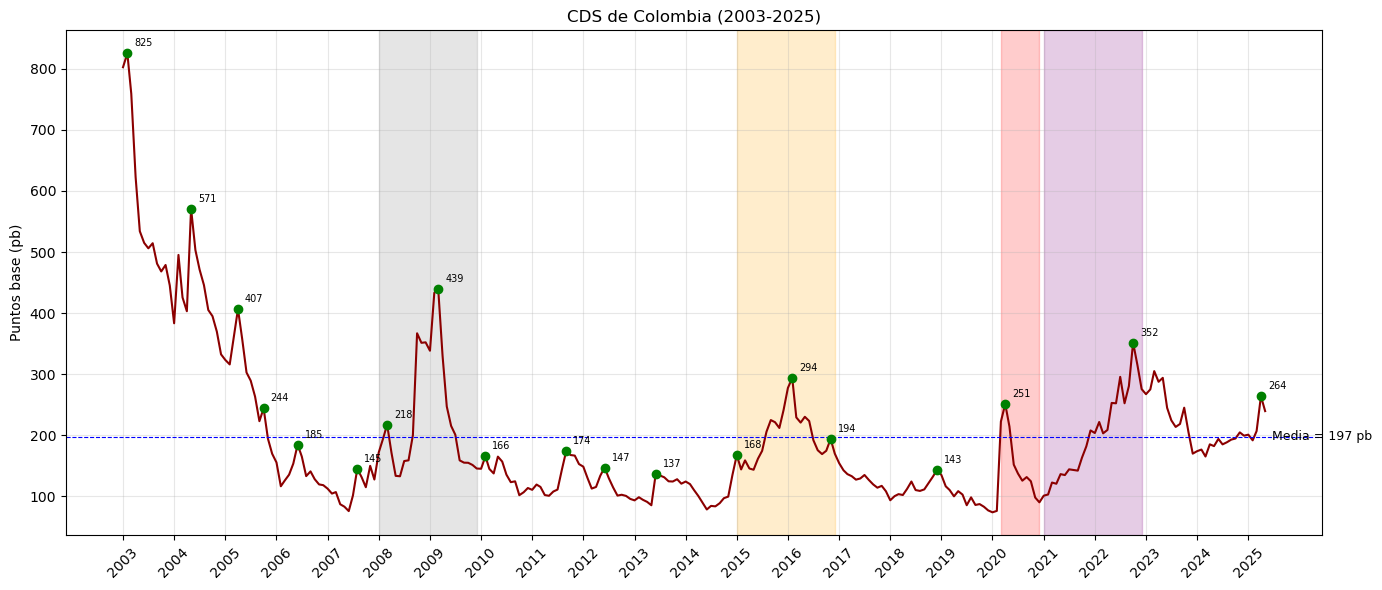

In [110]:

plt.figure(figsize=(14,6))
plt.plot(cds.index, cds.values, color='darkred', linewidth=1.5)

# Eje X con todos los años (frecuencia YS = inicio de año)
years = pd.date_range(start=cds.index[0], end=cds.index[-1], freq='YS')
plt.xticks(years, years.year, rotation=45)

# Sombreado de periodos de estrés identificados
plt.axvspan('2008-01-01', '2009-12-01', alpha=0.2, color='gray')
plt.axvspan('2015-01-01', '2016-12-01', alpha=0.2, color='orange')
plt.axvspan('2020-03-01', '2020-12-01', alpha=0.2, color='red')
plt.axvspan('2021-01-01', '2022-12-01', alpha=0.2, color='purple')

# Línea de la media
media_cds = cds.mean()
plt.axhline(y=media_cds, color='blue', linestyle='--', linewidth=0.8)
plt.annotate(f'Media = {media_cds:.0f} pb', xy=(cds.index[-1], media_cds),
             xytext=(5, 0), textcoords='offset points', fontsize=9, ha='left', va='center')

# Detección automática de picos
peaks, _ = find_peaks(cds.values, distance=6, prominence=20)
plt.plot(cds.index[peaks], cds.values[peaks], 'go', markersize=6)
for p in peaks:
    plt.annotate(f'{cds.values[p]:.0f}', xy=(cds.index[p], cds.values[p]),
                 xytext=(5, 5), textcoords='offset points', fontsize=7)

plt.title('CDS de Colombia (2003-2025)', fontsize=12)
plt.ylabel('Puntos base (pb)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "fac.png", dpi=300, bbox_inches="tight")
plt.savefig(
    OUTPUT_FIGURES / "serie_cds_colombia_2003_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

La serie de CDS para Colombia entre 2003 y 2025 evidencia una alta sensibilidad frente a episodios de crisis financieras internacionales y choques de incertidumbre económica. Durante los primeros años de la muestra se observan los niveles más elevados de riesgo soberano, alcanzando un máximo cercano a 825 puntos básicos en 2003, reflejando un contexto de elevada percepción de riesgo sobre economías emergentes y condiciones financieras aún frágiles para Colombia.

A partir de 2003 y hasta aproximadamente 2007 se observa una fuerte reducción del CDS, en un contexto caracterizado por el auge de los precios internacionales del petróleo, la entrada de capitales hacia economías emergentes y una mejora general en los fundamentos macroeconómicos del país. El boom petrolero de los años 2000 favoreció el crecimiento económico, fortaleció las cuentas externas y contribuyó a una menor percepción de riesgo soberano.

Sin embargo, la crisis financiera global de 2008-2009 generó un nuevo incremento significativo del riesgo país, con valores cercanos a 439 puntos básicos. Más adelante, entre 2010 y 2014, la serie muestra relativa estabilidad y niveles moderados de riesgo.

Entre 2015 y 2016 se registra otro episodio de incremento, asociado en gran medida a la caída de los precios internacionales del petróleo y al deterioro de las condiciones externas para economías exportadoras de commodities como Colombia. En 2020 aparece un fuerte aumento relacionado con el choque global provocado por la pandemia de COVID-19, elevando nuevamente el CDS por encima de los 250 puntos básicos.

Por último, entre 2021 y 2023 se observa un periodo de elevada volatilidad y persistencia del riesgo, con un nuevo pico cercano a 352 puntos básicos, en un contexto marcado por incertidumbre fiscal, tensiones políticas y condiciones financieras internacionales más restrictivas. Hacia 2024 y 2025 la serie converge nuevamente hacia valores cercanos a la media histórica de 197 puntos básicos, aunque manteniendo niveles superiores a los observados durante los periodos de mayor estabilidad macroeconómica.

**FAC y FACP**

Para tener una idea sobre la dependencia temporal y orientar la identificación de modelos ARIMA, es necesario calcular la función de autocorrelación (ACF) y la función de autocorrelación parcial (PACF). La ACF mide la correlación lineal entre la serie y sus rezagos; un decaimiento lento sugiere no estacionariedad o alta persistencia. La PACF aísla la correlación directa con cada rezago, eliminando efectos intermedios, lo que ayuda a identificar el orden de un posible proceso autorregresivo (AR). Estos gráficos son el primer paso de la metodología Box-Jenkins después de inspeccionar la serie.

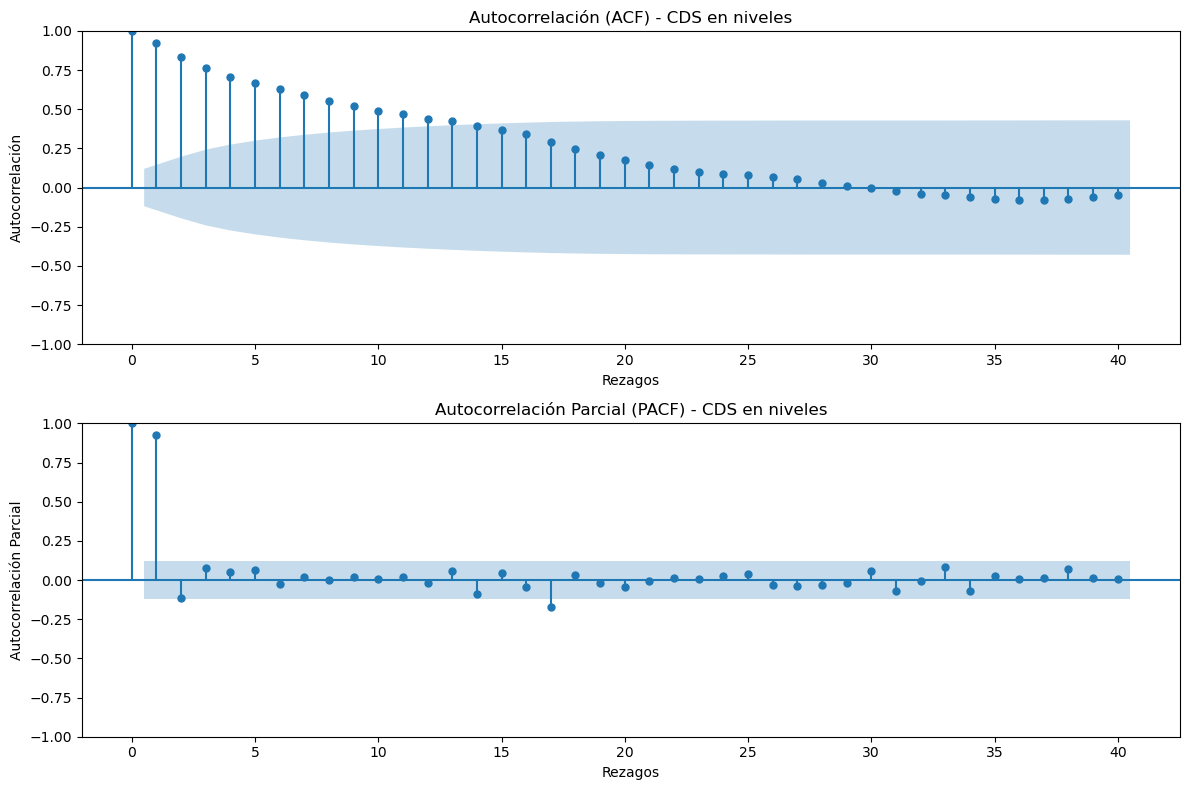

In [111]:
# Gráficos de ACF y PACF para la serie CDS en niveles 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Crear figura con dos subgráficos verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Graficar ACF con 40 rezagos y bandas de confianza al 95%
plot_acf(cds, ax=ax1, lags=40, alpha=0.05)
ax1.set_title('Autocorrelación (ACF) - CDS en niveles', fontsize=12)
ax1.set_xlabel('Rezagos')
ax1.set_ylabel('Autocorrelación')

# Graficar PACF con 40 rezagos y método Yule-Walker (ywm)
plot_pacf(cds, ax=ax2, lags=40, method='ywm', alpha=0.05)
ax2.set_title('Autocorrelación Parcial (PACF) - CDS en niveles', fontsize=12)
ax2.set_xlabel('Rezagos')
ax2.set_ylabel('Autocorrelación Parcial')

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "acf_pacf_niveles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La función de autocorrelación (ACF) muestra una persistencia elevada en la serie de CDS en niveles, ya que las correlaciones decreen lentamente y permanecen significativas durante varios rezagos. Este comportamiento sugiere que la serie no es estacionaria o presenta una fuerte dependencia temporal.

Por su parte, la función de autocorrelación parcial (PACF) evidencia un pico dominante en el primer rezago y una rápida disipación posterior, lo que sugiere una estructura autoregresiva de bajo orden, posiblemente compatible con un proceso AR(1). Así las cosas, ambos gráficos indican una alta inercia en la dinámica del CDS y justifican la necesidad de evaluar formalmente la estacionariedad de la serie mediante pruebas tales como Dickey Fuller, Dickey Fuller Aumentada y/o KPSS.

In [112]:
# Aplica la prueba de Dickey-Fuller a la serie CDS con solo constante.
# Se especifica maxlag=0 para que no incluya rezagos de la variable dependiente.
resultado = adfuller(cds, regression='c', maxlag=0, autolag=None)
print(f"DF estadístico: {resultado[0]:.4f}")
print(f"Valor p: {resultado[1]:.4f}")
print(f"Conclusión: {'Estacionaria' if resultado[1] < 0.05 else 'No estacionaria'}")

DF estadístico: -5.1178
Valor p: 0.0000
Conclusión: Estacionaria


La prueba de Dickey-Fuller (DF) arroja un estadístico de -5.1178 y un valor p de cero, permitiendo rechazar la hipótesis nula de raíz unitaria. En consecuencia, existe evidencia estadística a favor de la estacionariedad de la serie.

No obstante, la ACF exhibe una persistencia elevada y una disminución gradual de las autocorrelaciones, patrón común en procesos altamente persistentes. Por ello, aunque la prueba formal rechaza no estacionariedad, la dinámica de la serie sugiere cautela en la interpretación y justifica complementar el análisis con otras pruebas y criterios econométricos.

In [113]:
# ADF con constante y con criterio AIC para rezagos

# Se incluye autolag='AIC' para seleccionar el número óptimo de rezagos.
adf_c = adfuller(cds, regression='c', autolag='AIC')
print("ADF con constante:")
print(f"  estadístico = {adf_c[0]:.4f}, p-valor = {adf_c[1]:.4f}")

# KPSS con constante (hipótesis nula: serie estacionaria en niveles)
kpss_c = kpss(cds, regression='c', nlags='auto')
print("\nKPSS con constante:")
print(f"  estadístico = {kpss_c[0]:.4f}, p-valor = {kpss_c[1]:.4f}")

ADF con constante:
  estadístico = -5.6075, p-valor = 0.0000

KPSS con constante:
  estadístico = 0.6767, p-valor = 0.0157


La prueba ADF (con constantes) rechaza raíz unitaria (p≈0), indicando estacionariedad. La prueba KPSS (con constante) rechaza estacionariedad (p=0.0157). Esta contradicción es típica en series con alta persistencia y cambios estructurales. El ADF carece de potencia para distinguir una raíz unitaria de un proceso estacionario pero muy persistente (coeficiente AR cercano a 1), mientras que el KPSS es más sensible a la persistencia de largo plazo. El conflicto sugiere que la serie no es claramente estacionaria, por lo que se recomienda diferenciar.

### **Serie en Primera Diferencia**

In [114]:
# Se calcula la primera diferencia para evaluar si elimina la dependencia serial.

# Para eliminar el primer valor faltante (NaN) generado por la diferenciación se usa "dropna()",
# ya que la primera observación no tiene un valor previo contra el cual calcular la diferencia.

cds_diff = cds.diff().dropna()

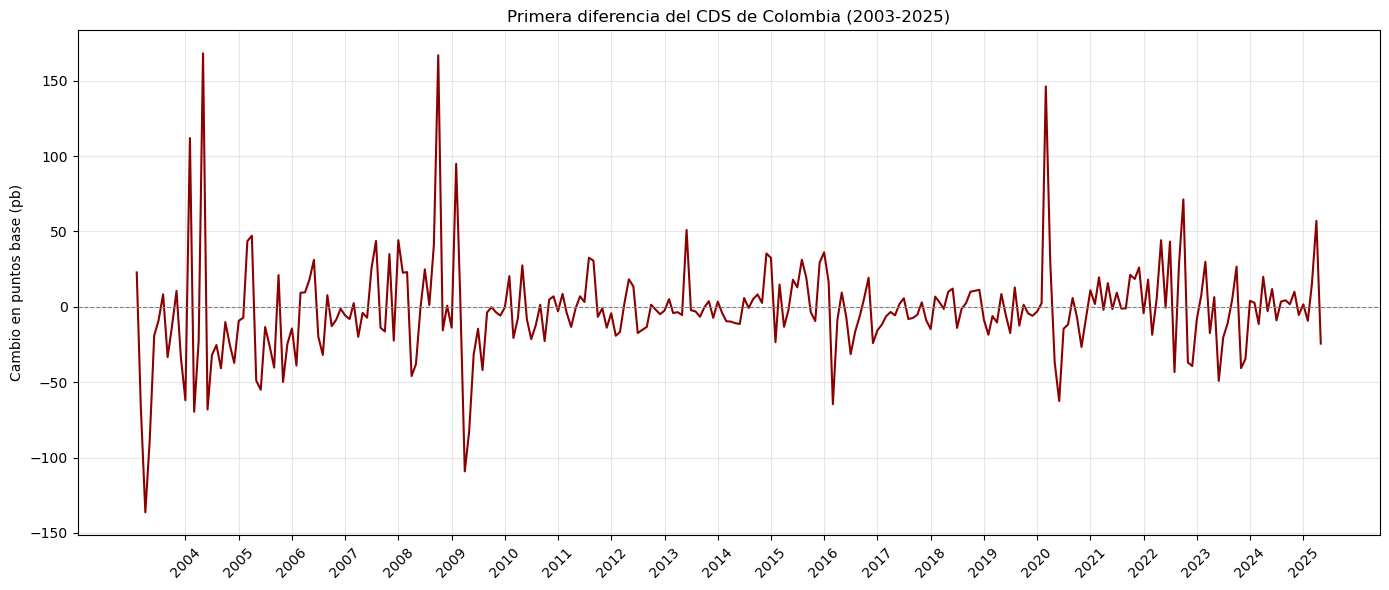

In [115]:
# Configurar tamaño de la figura (similar al gráfico de niveles)
plt.figure(figsize=(14,6))

# Graficar la primera diferencia del CDS
plt.plot(cds_diff.index, cds_diff.values, color='darkred', linewidth=1.5)

# Línea horizontal en cero para referencia
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Configurar el eje X con todos los años (frecuencia 'YS' = inicio de año)
years = pd.date_range(start=cds_diff.index[0], end=cds_diff.index[-1], freq='YS')
plt.xticks(years, years.year, rotation=45)

# Títulos y etiquetas
plt.title('Primera diferencia del CDS de Colombia (2003-2025)', fontsize=12)
plt.ylabel('Cambio en puntos base (pb)')

# Cuadrícula con transparencia
plt.grid(alpha=0.3)

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

La primera diferencia del CDS representa el cambio mensual en la percepción de riesgo soberano de Colombia, es decir, cuánto aumentó o disminuyó el spread frente al periodo inmediatamente anterior. A diferencia de la serie en niveles, la serie diferenciada fluctúa alrededor de cero y presenta una media aproximadamente centrada en dicho valor.

Asimismo, la diferenciación reduce considerablemente la persistencia temporal y estabiliza parcialmente la varianza de la serie. Mientras la serie en niveles exhibía cambios prolongados y episodios de elevada volatilidad asociados a distintos regímenes de riesgo, la serie diferenciada muestra oscilaciones más acotadas y de menor duración, aunque todavía se observan choques importantes durante periodos de estrés financiero como la crisis de 2008-2009, el choque petrolero de 2015-2016 y la pandemia de COVID-19 en 2020.

Por tanto, el comportamiento de la serie diferenciada sugiere una dinámica más cercana a la estacionariedad, por lo que para este caso ya tendría sentido considerar la estimación de modelos ARIMA que representen la serie.

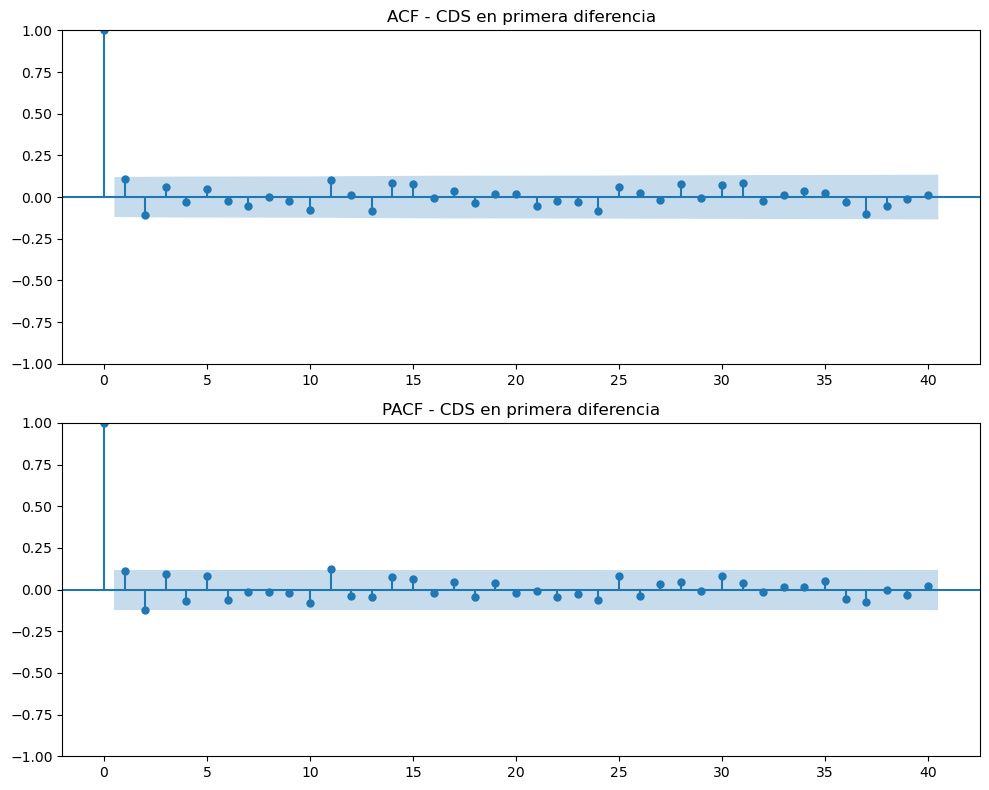

In [116]:
# Se grafican ACF y PACF de la serie diferenciada para inspeccionar si se vuelve ruido blanco
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(cds_diff, ax=ax1, lags=40,
         title='ACF - CDS en primera diferencia')

plot_pacf(cds_diff, ax=ax2, lags=40,
          method='ywm',
          title='PACF - CDS en primera diferencia')

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "acf_pacf_primera_diferencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Tras aplicar la primera diferencia, la estructura de dependencia serial disminuye considerablemente. La ACF ya no presenta el decaimiento lento observado en la serie en niveles y la mayoría de las autocorrelaciones se ubican dentro de las bandas de confianza.

De manera similar, la PACF no evidencia patrones autoregresivos persistentes, sugiriendo que gran parte de la dinámica temporal fue removida mediante la diferenciación.

Los resultados indican que la primera diferencia del CDS se comporta como una serie estacionaria de memoria corta, lo que refuerza la hipótesis de alta persistencia o posible raíz unitaria en la serie original en niveles.

In [117]:
# DF (no aumentada) con constante (sin tendencia)
df_diff = adfuller(cds_diff, regression='c', maxlag=0, autolag=None)
print("DF (no aumentada) - cds_diff")
print(f"  estadístico = {df_diff[0]:.4f}, p-valor = {df_diff[1]:.4f}")

# ADF (aumentada) con constante (selección automática de rezagos)
adf_diff = adfuller(cds_diff, regression='c', autolag='AIC')
print("\nADF (aumentada) - cds_diff")
print(f"  estadístico = {adf_diff[0]:.4f}, p-valor = {adf_diff[1]:.4f}")

# KPSS con constante (nula: estacionaria)
kpss_diff = kpss(cds_diff, regression='c', nlags='auto')
print("\nKPSS - cds_diff")
print(f"  estadístico = {kpss_diff[0]:.4f}, p-valor = {kpss_diff[1]:.4f}")

# Interpretación rápida
if adf_diff[1] < 0.05 and kpss_diff[1] > 0.05:
    print("\nConclusión: La primera diferencia es estacionaria (ADF rechaza raíz unitaria, KPSS no rechaza estacionariedad).")
else:
    print("\nConclusión: Resultados contradictorios; revisar.")

DF (no aumentada) - cds_diff
  estadístico = -14.5803, p-valor = 0.0000

ADF (aumentada) - cds_diff
  estadístico = -12.2986, p-valor = 0.0000

KPSS - cds_diff
  estadístico = 0.4330, p-valor = 0.0629

Conclusión: La primera diferencia es estacionaria (ADF rechaza raíz unitaria, KPSS no rechaza estacionariedad).


Los resultados de las pruebas de estacionariedad indican que la primera diferencia de la serie CDS puede considerarse estacionaria. Tanto la prueba Dickey-Fuller (DF) como la prueba Dickey-Fuller aumentada (ADF) rechazan de manera contundente la hipótesis nula de raíz unitaria, dado que sus valores p son prácticamente iguales a cero. Esto sugiere que la diferenciación logró eliminar la tendencia estocástica y la elevada persistencia observada en la serie en niveles.

Asimismo, la prueba KPSS arroja un valor p de 0.0629, por lo que no se rechaza la hipótesis nula de estacionariedad al 5% de significancia. Este resultado complementa la evidencia obtenida mediante las pruebas DF y ADF, indicando que la serie diferenciada fluctúa alrededor de una media relativamente estable y presenta una dinámica compatible con estacionariedad.

Las pruebas sugieren que la serie CDS es integrada de orden uno, \(I(1)\), ya que requiere una diferenciación para alcanzar estacionariedad.

### Selección preliminar de modelos ARIMA

Dado que la serie en niveles exhibe alta persistencia y posibles características de no estacionariedad, mientras que la primera diferencia muestra un comportamiento mucho más estable y cercano a estacionario, se considerarán modelos ARIMA con una diferenciación (\(d=1\)).

La inspección de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) sugiere la posible presencia de componentes autoregresivos y de media móvil de bajo orden en la serie diferenciada. En consecuencia, se evaluarán especificaciones parsimoniosas que permitan capturar la dinámica temporal del CDS.

En particular, se considerarán los siguientes modelos:

- ARIMA(0,1,0) con constante, correspondiente a un paseo aleatorio con deriva.
- ARIMA(1,1,0), equivalente a un componente AR(1) sobre la serie diferenciada.
- ARIMA(0,1,1), equivalente a un componente MA(1) sobre la serie diferenciada.
- ARIMA(2,1,0), incorporando componentes autoregresivos adicionales.
- ARIMA(0,1,2), incorporando componentes de media móvil de mayor orden.

La comparación entre modelos se realizará con base en criterios de información y análisis de residuos, buscando identificar la especificación que capture adecuadamente la dinámica temporal del CDS.

In [118]:
# Se estiman seis modelos ARIMA sobre la serie CDS en niveles con d=1 (una diferenciación).
# trend='n' indica que el modelo no incluye constante ni deriva (especificación parsimoniosa).
# .fit() ajusta el modelo por máxima verosimilitud (MLE) y devuelve un objeto con los resultados.

# Modelo ARIMA(0,1,0): paseo aleatorio sin deriva (solo la diferenciación).
mod_010 = ARIMA(cds, order=(0,1,0), trend='n').fit()
# Modelo ARIMA(1,1,0): un rezago autorregresivo (AR(1)) sobre la serie diferenciada.
mod_ar1 = ARIMA(cds, order=(1,1,0), trend='n').fit()
# Modelo ARIMA(0,1,1): un rezago de media móvil (MA(1)) sobre la serie diferenciada.
mod_ma1 = ARIMA(cds, order=(0,1,1), trend='n').fit()
# Modelo ARIMA(1,1,1): un rezago autorregresivo y uno de media móvil.
mod_arma11 = ARIMA(cds, order=(1,1,1), trend='n').fit()
# Modelo ARIMA(2,1,0): dos rezagos autorregresivos (AR(2)) sobre la serie diferenciada.
mod_ar2 = ARIMA(cds, order=(2,1,0), trend='n').fit()
# Modelo ARIMA(0,1,2): dos rezagos de media móvil (MA(2)) sobre la serie diferenciada.
mod_ma2 = ARIMA(cds, order=(0,1,2), trend='n').fit()

# Impresión ordenada de los criterios de información AIC y BIC.
print("ARIMA(0,1,0): AIC={:.2f}, BIC={:.2f}".format(mod_010.aic, mod_010.bic))
print("ARIMA(1,1,0): AIC={:.2f}, BIC={:.2f}".format(mod_ar1.aic, mod_ar1.bic))
print("ARIMA(0,1,1): AIC={:.2f}, BIC={:.2f}".format(mod_ma1.aic, mod_ma1.bic))
print("ARIMA(1,1,1): AIC={:.2f}, BIC={:.2f}".format(mod_arma11.aic, mod_arma11.bic))
print("ARIMA(2,1,0): AIC={:.2f}, BIC={:.2f}".format(mod_ar2.aic, mod_ar2.bic))
print("ARIMA(0,1,2): AIC={:.2f}, BIC={:.2f}".format(mod_ma2.aic, mod_ma2.bic))

ARIMA(0,1,0): AIC=2621.54, BIC=2625.13
ARIMA(1,1,0): AIC=2620.05, BIC=2627.23
ARIMA(0,1,1): AIC=2618.86, BIC=2626.04
ARIMA(1,1,1): AIC=2609.83, BIC=2620.60
ARIMA(2,1,0): AIC=2617.97, BIC=2628.74
ARIMA(0,1,2): AIC=2615.22, BIC=2625.99


Los criterios AIC y BIC miden la calidad del ajuste penalizando la complejidad del modelo: a menor valor, mejor equilibrio entre bondad de ajuste y parsimonia.

- **ARIMA(0,1,0)** (paseo aleatorio sin deriva) presenta los valores más altos: AIC=2621.54, BIC=2625.13. Es el peor modelo.
- **ARIMA(1,1,0)** y **ARIMA(0,1,1)** mejoran el ajuste, con AIC y BIC menores.
- **ARIMA(1,1,1)** obtiene el **menor AIC (2609.83)** y también el **menor BIC (2620.60)**. Es el modelo preferido.
- **ARIMA(2,1,0)** y **ARIMA(0,1,2)** tienen peor AIC/BIC que ARIMA(1,1,1), indicando que añadir más rezagos no mejora el ajuste.

Por tanto, se selecciona **ARIMA(1,1,1)** como modelo final para la serie CDS en niveles. Este modelo incorpora un término autorregresivo y uno de media móvil sobre la serie diferenciada, capturando adecuadamente la persistencia sin sobreparametrizar.

Por otra parte, las diferencias entre criterios de información como AIC o BIC pueden ser relativamente pequeñas debido a que varios modelos ARIMA parsimoniosos logran capturar de manera similar la dinámica temporal de la serie diferenciada. En contextos donde la estructura de dependencia es débil o de corto plazo, modelos cercanos entre sí —por ejemplo, ARIMA(1,1,0) y ARIMA(0,1,1)— suelen producir ajustes estadísticamente muy parecidos.

Por esta razón, para este estudio se considerará inicialmente el modelo ARIMA(1,1,1) para la serie CDS. Antes de analizar e interpretar los parámetros estimados mediante `fit`, se procederá a realizar el análisis de residuales con el fin de verificar si el modelo captura adecuadamente la dinámica temporal de la serie y si los errores se comportan como ruido blanco, es decir, sin autocorrelación ni patrones sistemáticos remanentes.

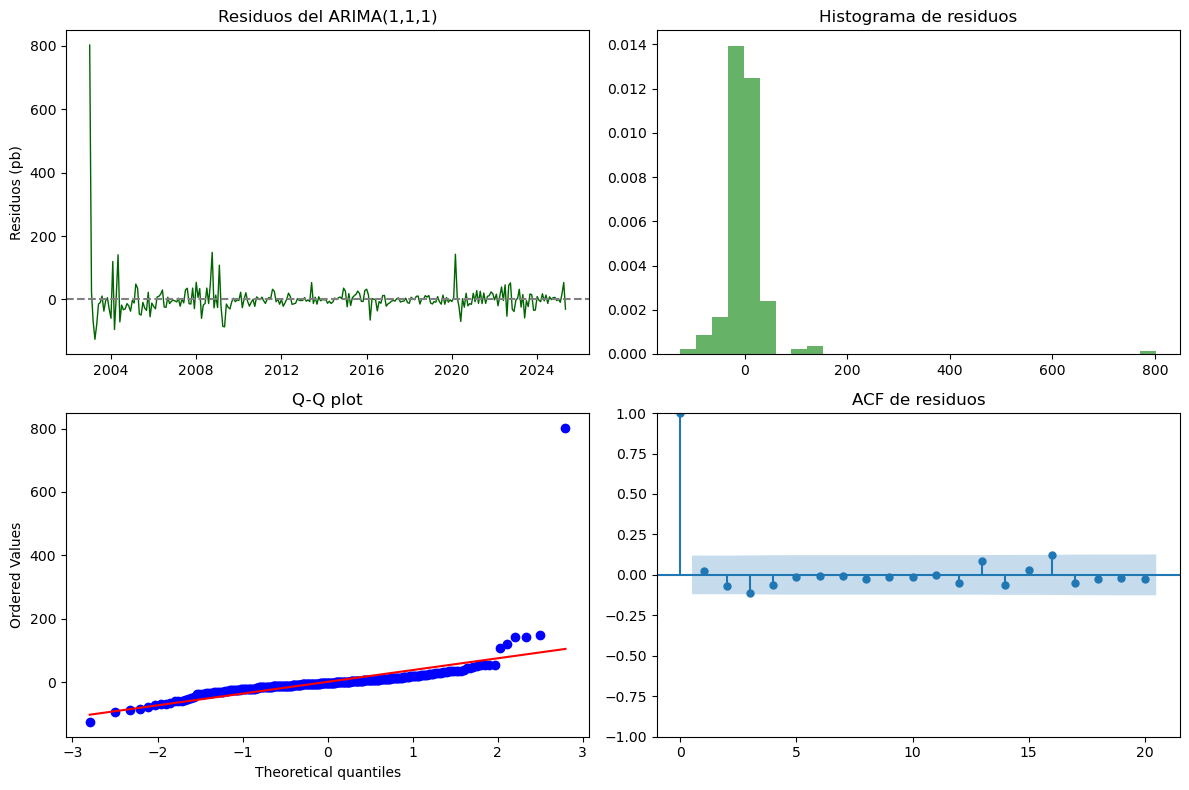

In [119]:
# Obtener los residuos del modelo seleccionado
residuos = mod_arma11.resid

# Gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Serie temporal de residuos
axes[0,0].plot(residuos.index, residuos.values, color='darkgreen', linewidth=1)
axes[0,0].axhline(y=0, color='gray', linestyle='--')
axes[0,0].set_title('Residuos del ARIMA(1,1,1)')
axes[0,0].set_ylabel('Residuos (pb)')

# Histograma con densidad
axes[0,1].hist(residuos, bins=30, density=True, alpha=0.6, color='green')
axes[0,1].set_title('Histograma de residuos')

# Q-Q plot para normalidad
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q plot')

# ACF de residuos
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, ax=axes[1,1], lags=20, title='ACF de residuos')

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "diagnostico_residuos_arima_111.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El análisis gráfico de los residuos del modelo ARIMA(1,1,1) sugiere que la especificación captura adecuadamente gran parte de la dinámica temporal de la serie CDS. En el gráfico temporal de residuos se observa que, salvo algunos episodios extremos asociados a periodos de crisis, los errores fluctúan alrededor de cero y no presentan patrones sistemáticos persistentes.

La función de autocorrelación (ACF) de los residuos muestra que la mayoría de las autocorrelaciones se encuentran dentro de las bandas de confianza, lo que indica ausencia de dependencia serial significativa remanente. Esto sugiere que el modelo logró absorber adecuadamente la estructura temporal de la serie.

Por otra parte, el histograma y el gráfico Q-Q evidencian desviaciones respecto a la normalidad, particularmente por la presencia de colas pesadas y valores atípicos extremos asociados a episodios de elevada volatilidad financiera. Asimismo, la prueba de heterocedasticidad (veáse siguiente bloque) reportada por el modelo rechaza la hipótesis de varianza constante en los residuos, sugiriendo la presencia de cambios en la volatilidad a lo largo del tiempo. No obstante, no se estimaron modelos específicos de volatilidad condicional, como ARCH o GARCH, dado que dicho análisis excede el alcance del presente estudio.

De este modo, los resultados sugieren que el modelo presenta un ajuste razonable en términos de dependencia temporal, aunque persisten características típicas de series financieras, como presencia de choques extremos y posibles cambios en la volatilidad a lo largo del tiempo.

Con base en los criterios de información, el análisis de estacionariedad y el comportamiento de los residuos, se selecciona el modelo ARIMA(1,1,1) como especificación final para la serie CDS. Una vez verificado que el modelo captura razonablemente la dinámica temporal de la serie, se procede a analizar los parámetros estimados y su interpretación económica.

In [120]:
# Modelo seleccionado ARIMA(1,1,1) sin constante (trend='n')
modelo_1 = ARIMA(cds, order=(1,1,1), trend='n').fit()
print(modelo_1.summary())

                               SARIMAX Results                                
Dep. Variable:                    CDS   No. Observations:                  269
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1301.916
Date:                Thu, 28 May 2026   AIC                           2609.832
Time:                        20:06:41   BIC                           2620.605
Sample:                    01-01-2003   HQIC                          2614.159
                         - 05-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7406      0.069    -10.787      0.000      -0.875      -0.606
ma.L1          0.9079      0.052     17.404      0.000       0.806       1.010
sigma2       969.6517     48.042     20.183      0.0

Los resultados del modelo ARIMA(1,1,1) indican que tanto el componente autoregresivo como el componente de media móvil son estadísticamente significativos, dado que sus respectivos valores p son inferiores al 1%. El parámetro AR(1) estimado fue de -0.7406, mientras que el componente MA(1) fue de 0.9079, lo que sugiere una dinámica de corto plazo importante en la evolución de la primera diferencia del CDS.

La ecuación estimada del modelo puede expresarse como:

$$
\Delta CDS_t = -0.7406 \Delta CDS_{t-1} + \varepsilon_t + 0.9079 \varepsilon_{t-1}
$$

donde $\Delta CDS_t$ representa la primera diferencia de la serie CDS y $\varepsilon_t$ corresponde al término de error aleatorio.

El test de Ljung-Box presenta un valor p de 0.95, lo que indica que no existe evidencia significativa de autocorrelación remanente en los residuos. En consecuencia, el modelo parece capturar adecuadamente la dependencia temporal de la serie.

Sin embargo, el test de Jarque-Bera rechaza la hipótesis de normalidad de los residuos (p-valor = 0.00), evidenciando asimetrías y colas pesadas, características frecuentes en series financieras. Asimismo, la prueba de heterocedasticidad también rechaza la hipótesis de varianza constante, sugiriendo cambios en la volatilidad de los errores a lo largo del tiempo.

## Pronóstico del modelo ARIMA(1,1,1)

Una vez estimado y validado el modelo ARIMA(1,1,1), se procede a generar pronósticos para los siguientes diez meses de la serie CDS. El pronóstico incluye tanto la trayectoria esperada de la variable como sus respectivos intervalos de confianza al 95%, permitiendo evaluar el nivel de incertidumbre asociado a las predicciones.

La estimación se realiza sobre la serie en niveles, utilizando la dinámica temporal capturada por el modelo ajustado previamente.

In [121]:
# Generar fechas para los próximos 10 meses (frecuencia mensual, inicio de mes)
ultima_fecha = cds.index[-1]  # Última fecha disponible de la serie histórica
fechas_pronostico = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1), periods=10, freq='MS')  # 10 fechas mensuales sucesivas

# Obtener pronóstico del modelo ARIMA(1,1,1) previamente estimado (mod_arma11)
pronostico = mod_arma11.get_forecast(steps=10)  # Genera objeto con predicciones y errores estándar
media = pronostico.predicted_mean  # Media puntual del pronóstico para cada horizonte
intervalo = pronostico.conf_int()  # Intervalos de confianza al 95% (por defecto)

# Construir DataFrame con los resultados ordenados
resultado = pd.DataFrame({
    'Fecha': fechas_pronostico,                     # Fechas futuras
    'Pronóstico_CDS': media.values,                 # Valores pronosticados (niveles)
    'LI_95%': intervalo.iloc[:, 0].values,          # Límite inferior del IC 95%
    'LS_95%': intervalo.iloc[:, 1].values           # Límite superior del IC 95%
})
print("\nPronóstico ARIMA(1,1,1) para CDS (niveles):\n", resultado)


Pronóstico ARIMA(1,1,1) para CDS (niveles):
        Fecha  Pronóstico_CDS      LI_95%      LS_95%
0 2025-06-01      229.895452  168.863681  290.927222
1 2025-07-01      237.086666  143.278003  330.895329
2 2025-08-01      231.760593  118.380061  345.141124
3 2025-09-01      235.705275  102.834012  368.576538
4 2025-10-01      232.783701   84.807563  380.759839
5 2025-11-01      234.947525   72.009883  397.885166
6 2025-12-01      233.344918   57.574455  409.115382
7 2026-01-01      234.531866   46.205415  422.858318
8 2026-02-01      233.652770   33.974907  433.330632
9 2026-03-01      234.303861   23.592730  445.014991


Los pronósticos generados por el modelo ARIMA(1,1,1) sugieren una relativa estabilización del CDS colombiano alrededor de valores cercanos a 230-235 puntos básicos durante el horizonte proyectado entre junio de 2025 y marzo de 2026. La trayectoria esperada no muestra una tendencia creciente o decreciente marcada, lo que indica que el modelo anticipa una dinámica relativamente estable en la percepción de riesgo soberano de corto plazo.

Sin embargo, los intervalos de confianza al 95% se amplían progresivamente a medida que aumenta el horizonte de pronóstico. Mientras para junio de 2025 el intervalo estimado se encuentra aproximadamente entre 169 y 291 puntos básicos, para marzo de 2026 el rango se expande entre 24 y 445 puntos básicos. Este comportamiento refleja el aumento natural de la incertidumbre en modelos de series de tiempo conforme las predicciones se alejan del periodo observado.

Asimismo, la amplitud creciente de los intervalos sugiere que, aunque el modelo identifica un nivel promedio esperado relativamente estable, persiste una elevada incertidumbre asociada a posibles choques financieros, cambios en las condiciones internacionales o episodios de volatilidad que afectan el riesgo soberano colombiano.

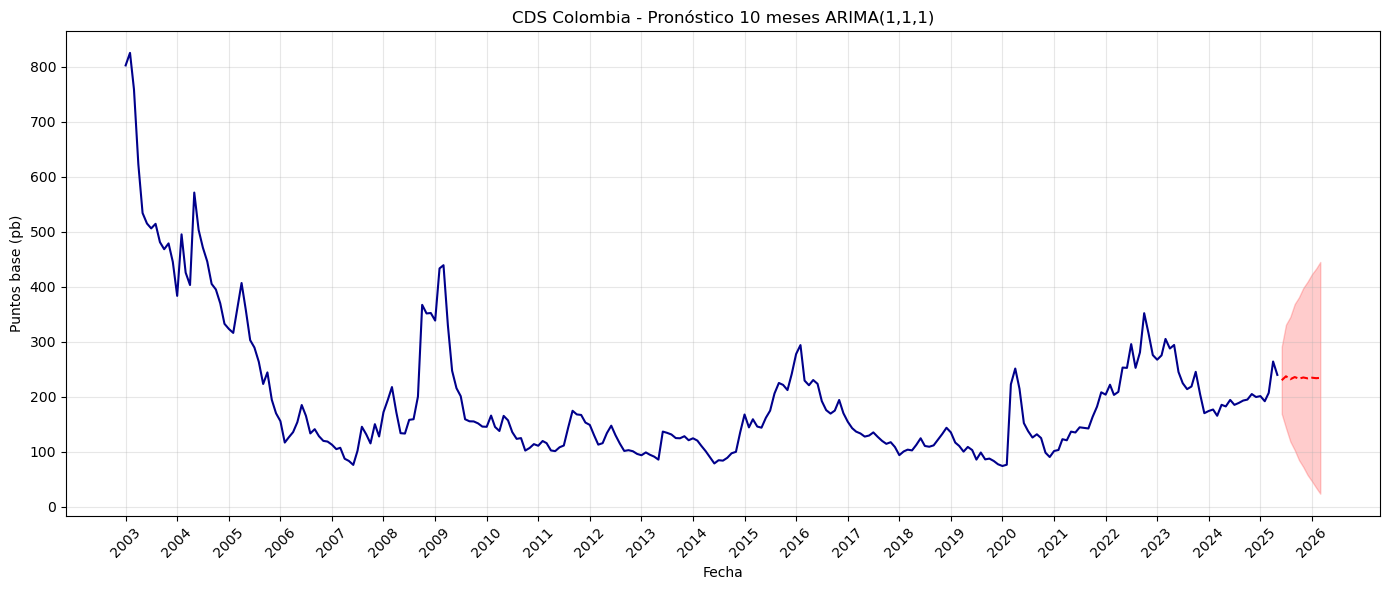

In [122]:
# Gráfico histórico + pronóstico con bandas de confianza

plt.figure(figsize=(14,6))

# Serie histórica
plt.plot(cds.index, cds.values,
         color='darkblue',
         linewidth=1.5)

# Pronóstico
plt.plot(resultado['Fecha'],
         resultado['Pronóstico_CDS'],
         'r--',
         linewidth=1.5)

# Banda de confianza al 95%
plt.fill_between(resultado['Fecha'],
                 resultado['LI_95%'],
                 resultado['LS_95%'],
                 color='red',
                 alpha=0.2)

# Configurar el eje X con todos los años
years = pd.date_range(start=cds.index[0],
                      end=resultado['Fecha'].max(),
                      freq='YS')

plt.xticks(years, years.year, rotation=45)

# Títulos y etiquetas
plt.title('CDS Colombia - Pronóstico 10 meses ARIMA(1,1,1)', fontsize=12)
plt.xlabel('Fecha')
plt.ylabel('Puntos base (pb)')

# Cuadrícula
plt.grid(alpha=0.3)

# Ajuste de márgenes
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "pronostico_cds_arima_111_10_meses.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Pronóstico del CDS mediante ARIMA(1,1,1)

El modelo ARIMA(1,1,1) genera una trayectoria pronosticada relativamente estable para el CDS de Colombia en el corto plazo, convergiendo hacia niveles cercanos a los valores más recientes observados.

No obstante, los intervalos de confianza se amplían rápidamente conforme aumenta el horizonte de pronóstico, reflejando la elevada incertidumbre inherente a la dinámica del CDS y la acumulación de shocks característica de procesos integrados.

En últimas, los resultados sugieren que el modelo logra capturar adecuadamente la dinámica promedio de corto plazo, aunque la capacidad predictiva disminuye en horizontes más largos debido a la alta volatilidad y persistencia de la serie.

### Extensión del análisis mediante transformación logarítmica

Dado que el modelo ARIMA estimado sobre la serie original presenta evidencia de heterocedasticidad, no normalidad en los residuos e intervalos de pronóstico que se amplían considerablemente en horizontes largos, se procederá a evaluar una transformación logarítmica del CDS con el fin de estabilizar parcialmente la varianza y reducir el impacto de valores extremos característicos de series financieras.

En primer lugar, se analizará la estacionariedad de $\log(CDS)$ mediante pruebas ADF y KPSS. Posteriormente, se examinarán las funciones ACF y PACF para identificar posibles estructuras autoregresivas y de media móvil, evaluando distintas especificaciones ARIMA con base en criterios de información y análisis residual.

Una vez seleccionado el modelo más adecuado, se realizarán pronósticos sobre la serie transformada y se reexpresarán en niveles originales mediante exponenciación. Sin embargo, debido a que la función exponencial es no lineal, la retransfomación puede introducir sesgos en los pronósticos, ya que el valor esperado de una variable en logaritmos no coincide exactamente con la exponenciación de su esperanza. En consecuencia, aplicar únicamente la función exponencial sobre los pronósticos en logaritmos tiende a subestimar los valores esperados en la escala original. Por esta razón, se incorporará un ajuste basado en la varianza residual del modelo, el cual permite corregir parcialmente dicho sesgo al considerar la dispersión de los errores durante la retransfomación.

Finalmente, se compararán los resultados obtenidos frente al modelo estimado sobre la serie en niveles, particularmente en términos de comportamiento residual, estabilidad de la varianza, amplitud de intervalos de confianza y desempeño predictivo.

In [123]:
# Aplicar logaritmo a CDS para estabilizar varianza 

log_cds = np.log(cds)

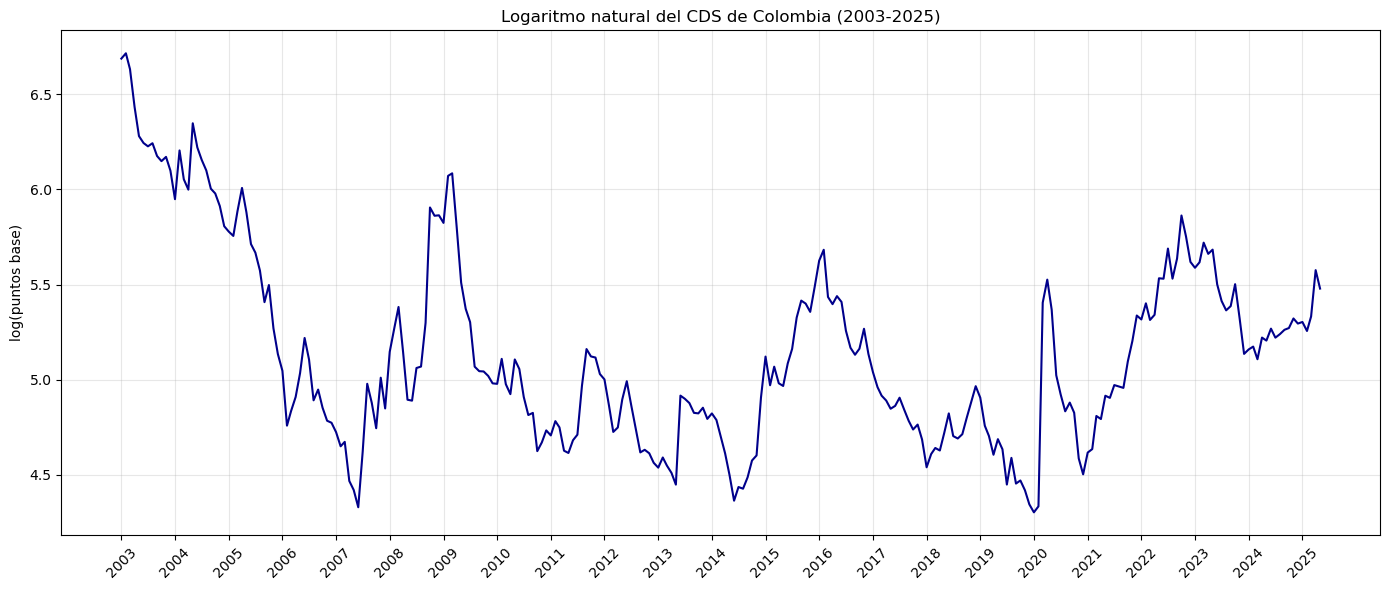

In [124]:
# Gráfico del logaritmo natural del CDS 
plt.figure(figsize=(14,6))  # Tamaño consistente con gráficos anteriores

# Graficar log_cds
plt.plot(log_cds.index, log_cds.values, color='darkblue', linewidth=1.5)

# Configurar el eje X con todos los años (frecuencia 'YS' = inicio de año)
years = pd.date_range(start=log_cds.index[0], end=log_cds.index[-1], freq='YS')
plt.xticks(years, years.year, rotation=45)

# Títulos y etiquetas
plt.title('Logaritmo natural del CDS de Colombia (2003-2025)', fontsize=12)
plt.ylabel('log(puntos base)')

# Cuadrícula con transparencia
plt.grid(alpha=0.3)

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.savefig(
    OUTPUT_FIGURES / "logaritmo_cds_colombia.png",
    dpi=300,
    bbox_inches="tight"
)

La transformación logarítmica del CDS permite reducir parcialmente la dispersión observada en la serie original, suavizando la magnitud de los picos extremos y estabilizando en cierta medida la varianza a lo largo del tiempo. En comparación con la serie en niveles, el logaritmo natural presenta oscilaciones menos abruptas y una dinámica visualmente más homogénea, característica deseable para el análisis econométrico de series financieras.

Sin embargo, aunque la transformación logarítmica mejora el comportamiento de la serie, todavía se observa una elevada persistencia temporal y posibles indicios de no estacionariedad. La serie continúa exhibiendo movimientos prolongados y dependencia serial importante, por lo que resulta necesario aplicar nuevamente una diferenciación para eliminar la tendencia estocástica y aproximar la serie a un comportamiento estacionario.

In [125]:
# Rendimientos logarítmicos (cambio porcentual aproximado)
dlog_cds = log_cds.diff().dropna()

In [126]:
d2log_cds = dlog_cds.diff().dropna()

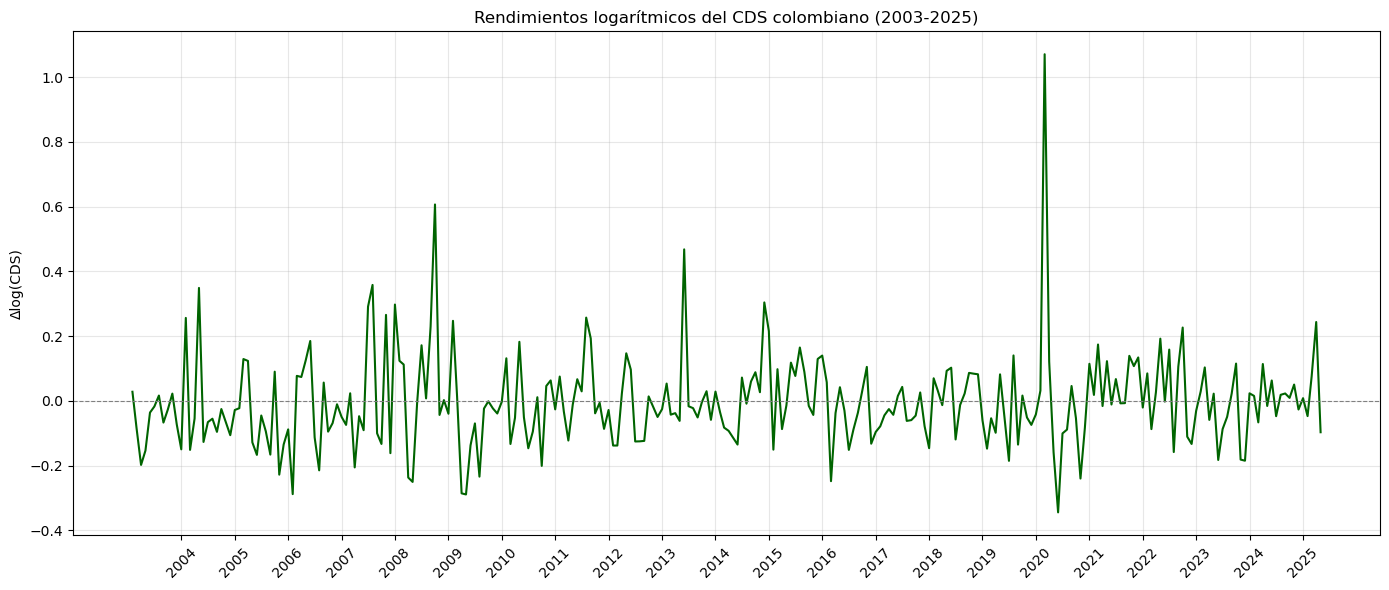

In [127]:
# Rendimientos logarítmicos (cambio porcentual aproximado)
dlog_cds = log_cds.diff().dropna()

# Formato de gráfico consistente con los anteriores
plt.figure(figsize=(14,6))  # Mismo tamaño que en niveles y log
plt.plot(dlog_cds.index, dlog_cds.values, color='darkgreen', linewidth=1.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Eje X con todos los años
years = pd.date_range(start=dlog_cds.index[0], end=dlog_cds.index[-1], freq='YS')
plt.xticks(years, years.year, rotation=45)

plt.title('Rendimientos logarítmicos del CDS colombiano (2003-2025)', fontsize=12)
plt.ylabel('Δlog(CDS)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La serie de rendimientos logarítmicos del CDS colombiano presenta un comportamiento considerablemente más estable que la serie original en niveles y que el logaritmo sin diferenciar. Los cambios porcentuales del CDS fluctúan alrededor de cero, sin evidencia visual de tendencia persistente, lo que sugiere una reducción importante de la dependencia temporal y una dinámica más cercana a la estacionariedad.

Asimismo, la transformación mediante logaritmos y diferenciación contribuye a estabilizar parcialmente la varianza de la serie, reduciendo la magnitud relativa de los cambios extremos observados en la serie original. La mayor parte de las observaciones se concentra alrededor de cero y dentro de un rango relativamente acotado, aunque todavía persisten algunos episodios de volatilidad elevada asociados a eventos de estrés financiero, particularmente durante la crisis internacional de 2008-2009 y el choque derivado de la pandemia en 2020.

En términos económicos, los rendimientos logarítmicos representan variaciones porcentuales aproximadas del CDS entre un periodo y otro, permitiendo interpretar los movimientos de la serie en términos relativos y no absolutos. Esta transformación resulta especialmente útil en series financieras, ya que facilita el análisis econométrico y reduce parcialmente problemas asociados a heterocedasticidad y presencia de valores extremos.

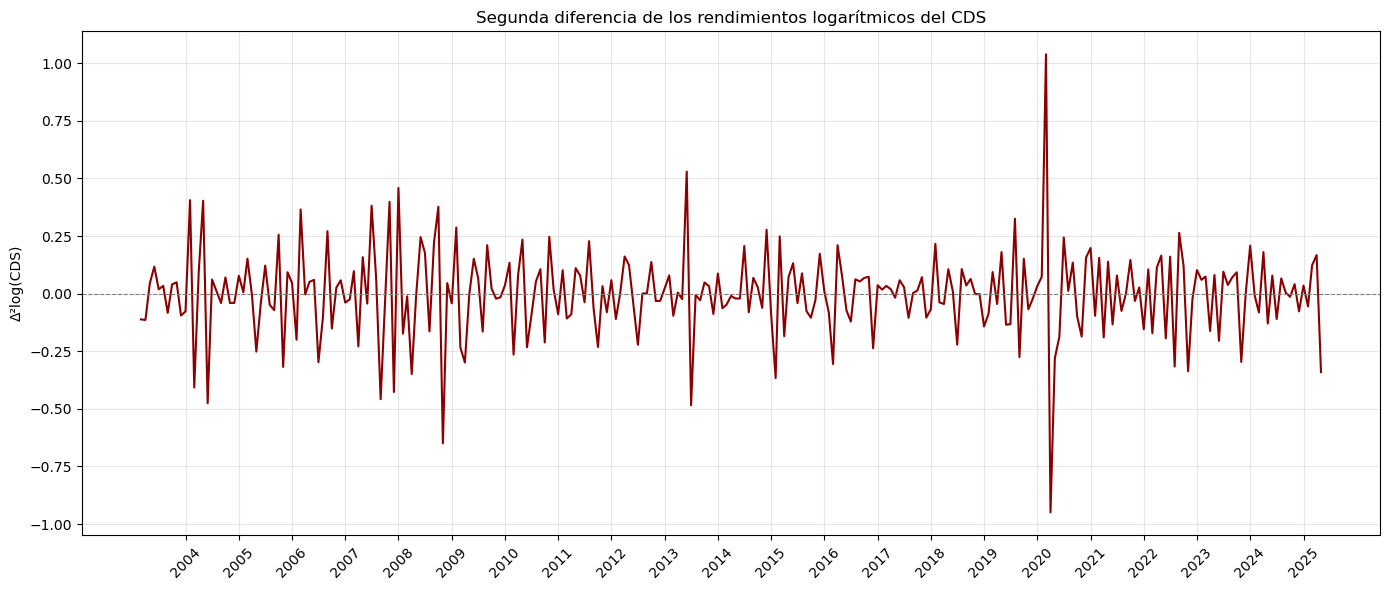

In [128]:
# Segunda diferencia de los rendimientos logarítmicos (doble diferenciación)
d2log_cds = dlog_cds.diff().dropna()

# Gráfico con el mismo formato estándar
plt.figure(figsize=(14,6))
plt.plot(d2log_cds.index, d2log_cds.values, color='darkred', linewidth=1.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Eje X con todos los años
years = pd.date_range(start=d2log_cds.index[0], end=d2log_cds.index[-1], freq='YS')
plt.xticks(years, years.year, rotation=45)

plt.title('Segunda diferencia de los rendimientos logarítmicos del CDS', fontsize=12)
plt.ylabel('Δ²log(CDS)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_FIGURES / "segunda_diferencia_log_cds.png",
    dpi=300,
    bbox_inches="tight"
)

Aunque la segunda diferencia de la serie presenta un comportamiento visualmente más cercano a la estacionariedad, su utilización implicaría una pérdida importante de interpretación económica y de estructura temporal relevante para el análisis del CDS. La primera diferencia ya logra eliminar la raíz unitaria y estabilizar considerablemente la dinámica de la serie, como lo evidencian las pruebas DF, ADF y KPSS.

En consecuencia, aplicar una segunda diferenciación podría conducir a un problema de sobre-diferenciación, eliminando información útil para la modelación y aumentando el carácter mecánico y ruidoso de la serie. Además, mientras la primera diferencia conserva una interpretación económica clara como cambio absoluto del CDS —o variación porcentual aproximada en el caso logarítmico—, la segunda diferencia representa cambios en dichas variaciones, dificultando su interpretación financiera.

Por estas razones, el análisis posterior se concentrará en modelos con una única diferenciación, privilegiando un balance entre estacionariedad, capacidad predictiva e interpretabilidad económica.

### Rendimientos logarítmicos del CDS colombiano

La serie de rendimientos logarítmicos del CDS exhibe un comportamiento considerablemente más estable que la serie original en niveles y que el logaritmo del CDS sin diferenciar. Visualmente, la serie fluctúa alrededor de cero, sin tendencia aparente y con una varianza relativamente más homogénea a lo largo del tiempo.

La transformación mediante diferencias logarítmicas reduce significativamente la persistencia observada previamente y elimina gran parte de la dependencia acumulativa de los shocks, lo que sugiere un comportamiento más cercano a estacionariedad.

No obstante, aún se observan episodios de volatilidad elevada y valores extremos, particularmente durante períodos de estrés financiero internacional como la crisis de 2008-2009 y el choque asociado a la pandemia de 2020. Tales patrones son consistentes con características típicas de series financieras, incluyendo heterocedasticidad condicional y agrupamiento de volatilidad.

In [129]:
# Pruebas de raíz unitaria para los rendimientos logarítmicos (dlog_cds)

# DF (no aumentada) sin constante (maxlag=0)
# Se usa regression='n' porque la serie ya fluctúa alrededor de cero
# y no presenta una media distinta de cero visualmente evidente.

df_dlog = adfuller(dlog_cds, regression='n', maxlag=0, autolag=None)
print("DF (no aumentada) - Δlog CDS")
print(f"  estadístico = {df_dlog[0]:.4f}, p-valor = {df_dlog[1]:.4f}")

# ADF (aumentada) sin constante
adf_dlog = adfuller(dlog_cds, regression='n', autolag='AIC')
print("\nADF (aumentada) - Δlog CDS")
print(f"  estadístico = {adf_dlog[0]:.4f}, p-valor = {adf_dlog[1]:.4f}")

# KPSS con constante
# En KPSS se mantiene regression='c' para evaluar estacionariedad
# alrededor de una media constante.

kpss_dlog = kpss(dlog_cds, regression='c', nlags='auto')
print("\nKPSS - Δlog CDS")
print(f"  estadístico = {kpss_dlog[0]:.4f}, p-valor = {kpss_dlog[1]:.4f}")

# Interpretación
if adf_dlog[1] < 0.05 and kpss_dlog[1] > 0.05:
    print("\nConclusión: Δlog CDS es estacionaria.")
else:
    print("\nConclusión: Resultados contradictorios; revisar.")

DF (no aumentada) - Δlog CDS
  estadístico = -14.1858, p-valor = 0.0000

ADF (aumentada) - Δlog CDS
  estadístico = -11.7351, p-valor = 0.0000

KPSS - Δlog CDS
  estadístico = 0.1921, p-valor = 0.1000

Conclusión: Δlog CDS es estacionaria.


Las pruebas ADF y KPSS sobre la serie de rendimientos logarítmicos del CDS arrojan resultados consistentes a favor de la estacionariedad. La prueba ADF rechaza de manera contundente la hipótesis nula de raíz unitaria, mientras que la prueba KPSS no rechaza la hipótesis nula de estacionariedad.

Así, los resultados sugieren que la transformación mediante diferencias logarítmicas elimina la alta persistencia observada en la serie original y produce una serie estacionaria adecuada para modelación econométrica de corto plazo.

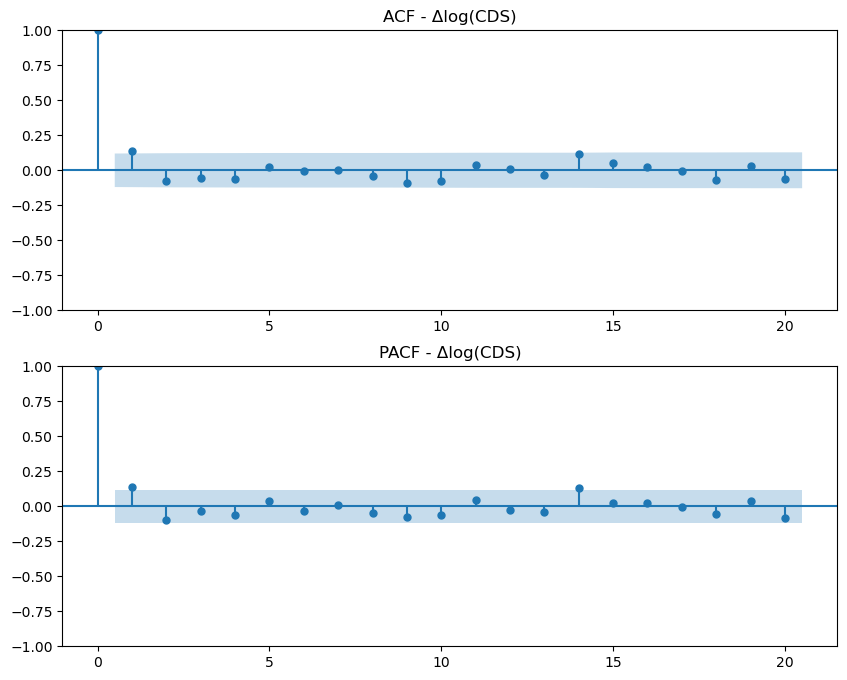

In [130]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(dlog_cds, ax=ax1, lags=20, title='ACF - Δlog(CDS)')
plot_pacf(dlog_cds, ax=ax2, lags=20, method='ywm', title='PACF - Δlog(CDS)')
plt.show()

Las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) de los rendimientos logarítmicos del CDS muestran una reducción importante de la dependencia serial observada en la serie original. La mayoría de las autocorrelaciones se encuentran dentro de las bandas de confianza, lo que sugiere un comportamiento mucho más cercano a la estacionariedad.

Tanto la ACF como la PACF presentan únicamente un rezago inicial levemente significativo, mientras que las autocorrelaciones posteriores desaparecen rápidamente y oscilan alrededor de cero sin patrones persistentes. Este comportamiento es consistente con procesos ARMA de bajo orden y evidencia que la transformación logarítmica junto con la diferenciación logró capturar gran parte de la persistencia temporal de la serie.

En términos econométricos, los gráficos sugieren que la dinámica de los rendimientos logarítmicos puede modelarse adecuadamente mediante especificaciones parsimoniosas, posiblemente con componentes autoregresivos o de media móvil de orden bajo, evitando estructuras excesivamente complejas.

Con base en el comportamiento de las funciones ACF y PACF, se considerarán distintas especificaciones ARMA de bajo orden para modelar los rendimientos logarítmicos del CDS colombiano. Dado que la serie diferenciada en logaritmos presenta una dinámica relativamente parsimoniosa y cercana a la estacionariedad, se evaluarán modelos con componentes autoregresivos y de media móvil simples, así como algunas especificaciones ligeramente más flexibles.

En particular, se estimarán los siguientes modelos:

- ARMA(0,0) con constante, correspondiente a un proceso de ruido blanco con media.
- ARMA(1,0), incorporando un componente autoregresivo de primer orden.
- ARMA(0,1), incorporando un componente de media móvil de primer orden.
- ARMA(1,1), combinando componentes autoregresivos y de media móvil de primer orden.

La selección del modelo final se realizará con base en criterios de información, significancia estadística de los parámetros y análisis de residuos, buscando un balance entre parsimonia, estabilidad estadística y capacidad predictiva.

In [131]:
# Se estiman cuatro modelos ARMA sobre los rendimientos logarítmicos (Δlog CDS).

# Se utiliza trend='n' (sin constante) porque la serie ya fluctúa alrededor de cero
# y no presenta evidencia visual de una media distinta de cero o deriva persistente.

# Modelo ARMA(0,0): ruido blanco sin términos AR ni MA
mod_00 = ARIMA(dlog_cds, order=(0,0,0), trend='n').fit()

# Modelo ARMA(1,0): autorregresivo de primer orden
mod_10 = ARIMA(dlog_cds, order=(1,0,0), trend='n').fit()

# Modelo ARMA(0,1): media móvil de primer orden
mod_01 = ARIMA(dlog_cds, order=(0,0,1), trend='n').fit()

# Modelo ARMA(1,1): autorregresivo y media móvil de primer orden
mod_11 = ARIMA(dlog_cds, order=(1,0,1), trend='n').fit()


# Impresión ordenada de los criterios AIC y BIC
print("ARMA(0,0) sin constante: AIC={:.2f}, BIC={:.2f}".format(mod_00.aic, mod_00.bic))
print("ARMA(1,0) sin constante: AIC={:.2f}, BIC={:.2f}".format(mod_10.aic, mod_10.bic))
print("ARMA(0,1) sin constante: AIC={:.2f}, BIC={:.2f}".format(mod_01.aic, mod_01.bic))
print("ARMA(1,1) sin constante: AIC={:.2f}, BIC={:.2f}".format(mod_11.aic, mod_11.bic))

ARMA(0,0) sin constante: AIC=-279.00, BIC=-275.41
ARMA(1,0) sin constante: AIC=-282.11, BIC=-274.93
ARMA(0,1) sin constante: AIC=-283.08, BIC=-275.90
ARMA(1,1) sin constante: AIC=-282.26, BIC=-271.49


Los criterios de información AIC y BIC sugieren que los modelos ARMA de bajo orden ofrecen ajustes relativamente similares para los rendimientos logarítmicos del CDS. Sin embargo, el modelo ARMA(0,1) presenta los menores valores tanto de AIC como de BIC, indicando el mejor balance entre capacidad de ajuste y parsimonia entre las especificaciones evaluadas.

Aunque el modelo ARMA(1,1) incorpora una estructura temporal más flexible, la mejora en ajuste no resulta suficiente para compensar el aumento en complejidad asociado a parámetros adicionales. De manera similar, el modelo ARMA(0,0) exhibe el peor desempeño relativo, lo que sugiere que aún existe cierta dependencia temporal que no puede ser explicada únicamente mediante ruido blanco.

En consecuencia, los resultados preliminares indican que una estructura de media móvil de primer orden captura adecuadamente la dinámica de corto plazo presente en los rendimientos logarítmicos del CDS colombiano.

In [132]:
# Obtener los residuos del modelo MA(1) sin constante (modelo_final_log)
residuos_log = modelo_final_log.resid

# Gráficos de diagnóstico (serie temporal, histograma, Q-Q, ACF de residuos)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Serie temporal de residuos
axes[0,0].plot(residuos_log.index, residuos_log.values, color='darkgreen', linewidth=1)
axes[0,0].axhline(y=0, color='gray', linestyle='--')
axes[0,0].set_title('Residuos del modelo MA(1) sobre Δlog CDS')
axes[0,0].set_ylabel('Residuos')

# Histograma con densidad
axes[0,1].hist(residuos_log, bins=30, density=True, alpha=0.6, color='green')
axes[0,1].set_title('Histograma de residuos')

# Q-Q plot para normalidad (no requerido pero útil)
from scipy import stats
stats.probplot(residuos_log, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q plot')

# ACF de residuos (debe mostrar ausencia de autocorrelación)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_log, ax=axes[1,1], lags=20, title='ACF de residuos')

plt.tight_layout()
plt.savefig(
    OUTPUT_FIGURES / "OUTPUT_FIGURES / "diagnostico_residuos_arma01_log.png"",
    dpi=300,
    bbox_inches="tight"
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2540581749.py, line 28)

El análisis gráfico de los residuos del modelo MA(1) estimado sobre los rendimientos logarítmicos del CDS muestra una mejora importante respecto al modelo ARIMA estimado sobre la serie diferenciada en niveles. En el gráfico temporal de residuos se observa una dispersión considerablemente más estable alrededor de cero y una reducción significativa en la magnitud de los valores extremos. Aunque persisten algunos episodios de volatilidad elevada, particularmente alrededor de 2020, los residuos presentan un comportamiento mucho más homogéneo que en el modelo estimado sobre la serie en niveles.

La función de autocorrelación (ACF) de los residuos indica que prácticamente todas las autocorrelaciones permanecen dentro de las bandas de confianza, lo que sugiere ausencia de dependencia serial remanente. Este resultado es consistente con el obtenido previamente para el modelo ARIMA(1,1,1), indicando que ambos modelos logran capturar adecuadamente la dinámica temporal de corto plazo.

Sin embargo, las diferencias más importantes aparecen en términos de estabilidad residual y comportamiento distributivo. En comparación con el modelo sobre la serie diferenciada en niveles, el histograma de residuos del modelo logarítmico presenta una distribución mucho más concentrada alrededor de cero y menos afectada por observaciones extremas. Asimismo, el gráfico Q-Q muestra una alineación más cercana a la línea teórica en gran parte de la distribución, aunque todavía persisten desviaciones importantes en las colas, especialmente por la presencia de choques financieros extremos.

A diferencia del modelo ARIMA estimado sobre la serie en niveles, el modelo MA(1) sobre rendimientos logarítmicos no presenta evidencia significativa de heterocedasticidad, resultado consistente con la reducción visual de la dispersión residual observada en los gráficos. Esto sugiere que la transformación logarítmica contribuyó efectivamente a estabilizar parcialmente la varianza y reducir el impacto relativo de episodios extremos sobre la dinámica de la serie.

Por tanto, los resultados indican que el modelo MA(1) sobre rendimientos logarítmicos ofrece un comportamiento residual más estable, parsimonioso y estadísticamente adecuado que el modelo ARIMA estimado sobre la serie diferenciada en niveles, particularmente en términos de homocedasticidad y estabilidad de la volatilidad.

In [ ]:
# Modelo final ARMA(0,1) sobre los rendimientos logarítmicos del CDS
# Se usa trend='n' porque la serie fluctúa alrededor de cero
# y no presenta una media distinta de cero visualmente relevante.

modelo_final_log = ARIMA(dlog_cds, order=(0,0,1), trend='n').fit()

# Resumen completo del modelo
print(modelo_final_log.summary())

                               SARIMAX Results                                
Dep. Variable:                    CDS   No. Observations:                  268
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 143.539
Date:                Thu, 28 May 2026   AIC                           -283.078
Time:                        18:26:43   BIC                           -275.896
Sample:                    02-01-2003   HQIC                          -280.193
                         - 05-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1622      0.063      2.565      0.010       0.038       0.286
sigma2         0.0201      0.001     29.883      0.000       0.019       0.021
Ljung-Box (L1) (Q):                   0.03   Jarque-

Los resultados del modelo ARMA(0,1) sobre los rendimientos logarítmicos del CDS indican que el componente de media móvil es estadísticamente significativo, dado que su valor p es inferior al 5%. El parámetro MA(1) estimado fue de 0.1622, lo que sugiere la presencia de una dependencia temporal de corto plazo relativamente moderada en las variaciones porcentuales del CDS.

La ecuación estimada del modelo puede expresarse como:

$$
\Delta \log(CDS_t) = \varepsilon_t + 0.1622 \varepsilon_{t-1}
$$

donde $\Delta \log(CDS_t)$ representa el rendimiento logarítmico del CDS y $\varepsilon_t$ corresponde al término de error aleatorio.

El test de Ljung-Box presenta un valor p de 0.86, lo que indica que no existe evidencia significativa de autocorrelación remanente en los residuos. En consecuencia, el modelo parece capturar adecuadamente la dependencia temporal de corto plazo presente en la serie.

Asimismo, la prueba de heterocedasticidad no rechaza la hipótesis de varianza constante en los residuos (p-valor = 0.86), sugiriendo una mejora importante respecto al modelo estimado sobre la serie en niveles. Esto indica que la transformación logarítmica contribuyó a estabilizar la volatilidad de la serie.

Sin embargo, el test de Jarque-Bera rechaza la hipótesis de normalidad de los residuos (p-valor = 0.00), evidenciando la persistencia de asimetrías y colas pesadas, características comunes en series financieras. El valor elevado de curtosis (15.19) y la asimetría positiva observada sugieren la presencia de eventos extremos y distribuciones alejadas de la normalidad gaussiana.

En conjunto, los resultados indican que el modelo ARMA(0,1) sobre rendimientos logarítmicos ofrece un comportamiento residual más estable y parsimonioso que el modelo estimado sobre la serie en niveles, particularmente en términos de homocedasticidad y estabilidad temporal.

In [ ]:
# Pronóstico del modelo MA(1) sobre rendimientos logarítmicos

forecast_dlog = modelo_final_log.get_forecast(steps=10)
resumen_dlog = forecast_dlog.summary_frame()

# Media y errores estándar del pronóstico
media_dlog = resumen_dlog['mean']
se_dlog = resumen_dlog['mean_se']

# Último valor observado en log(CDS)
ultimo_log = log_cds.iloc[-1]

# Reconstrucción acumulada en logaritmos
log_media = ultimo_log + media_dlog.cumsum()

# Intervalos de confianza acumulados
var_acum = (se_dlog**2).cumsum()

li_log = log_media - 1.96 * np.sqrt(var_acum)
ls_log = log_media + 1.96 * np.sqrt(var_acum)

# Retransformación a niveles
cds_media = np.exp(log_media)
cds_li = np.exp(li_log)
cds_ls = np.exp(ls_log)

# Fechas futuras
fechas_futuras = pd.date_range(
    start=cds.index[-1] + pd.DateOffset(months=1),
    periods=10,
    freq='MS'
)

# DataFrame final
df_pronostico_log = pd.DataFrame({
    'Fecha': fechas_futuras,
    'Pronóstico_CDS': cds_media,
    'LI_95%': cds_li,
    'LS_95%': cds_ls
})

print(df_pronostico_log.round({
    'Pronóstico_CDS': 2,
    'LI_95%': 2,
    'LS_95%': 2
}))

                Fecha  Pronóstico_CDS  LI_95%  LS_95%
2025-06-01 2025-06-01          234.44  177.62  309.45
2025-07-01 2025-07-01          234.44  157.92  348.05
2025-08-01 2025-08-01          234.44  144.35  380.77
2025-09-01 2025-09-01          234.44  133.84  410.68
2025-10-01 2025-10-01          234.44  125.22  438.95
2025-11-01 2025-11-01          234.44  117.91  466.17
2025-12-01 2025-12-01          234.44  111.56  492.67
2026-01-01 2026-01-01          234.44  105.97  518.69
2026-02-01 2026-02-01          234.44  100.97  544.36
2026-03-01 2026-03-01          234.44   96.46  569.81


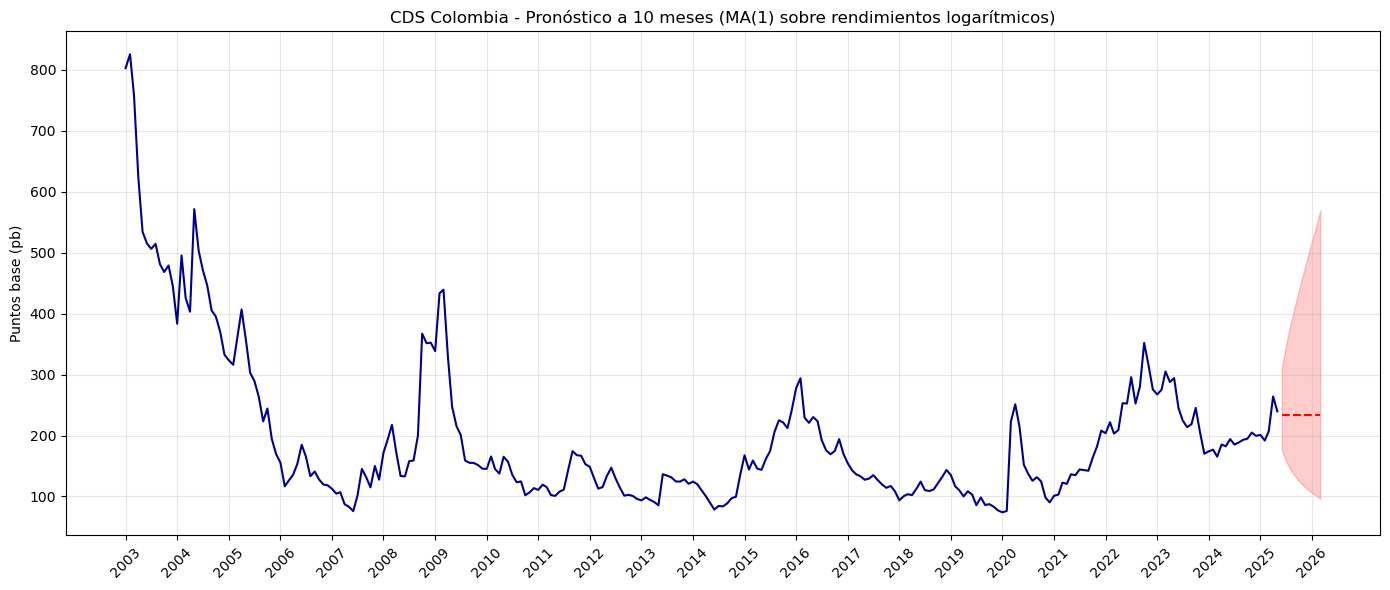

In [ ]:
# Gráfico final del pronóstico para el modelo MA(1) sobre rendimientos logarítmicos

plt.figure(figsize=(14,6))

# Serie histórica
plt.plot(cds.index, cds.values,
         color='darkblue',
         linewidth=1.5)

# Pronóstico
plt.plot(df_pronostico_log['Fecha'],
         df_pronostico_log['Pronóstico_CDS'],
         'r--',
         linewidth=1.5)

# Intervalos de confianza
plt.fill_between(df_pronostico_log['Fecha'],
                 df_pronostico_log['LI_95%'],
                 df_pronostico_log['LS_95%'],
                 color='red',
                 alpha=0.2)

# Eje X con todos los años hasta el final del pronóstico
years = pd.date_range(start=cds.index[0],
                      end=df_pronostico_log['Fecha'].max(),
                      freq='YS')

plt.xticks(years, years.year, rotation=45)

plt.title('CDS Colombia - Pronóstico a 10 meses (MA(1) sobre rendimientos logarítmicos)')
plt.ylabel('Puntos base (pb)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUTPUT_FIGURES / "pronostico_ma1_log.png",
    dpi=300,
    bbox_inches="tight"
)

In [133]:
# Asegurar mismas fechas futuras
ultima_fecha = cds.index[-1]
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1), periods=10, freq='MS')

# Pronóstico ARIMA(1,1,1) niveles
forecast_niveles = mod_arma11.get_forecast(steps=10)
media_niveles = forecast_niveles.predicted_mean
intervalo_niveles = forecast_niveles.conf_int()

# Pronóstico MA(1) sobre Δlog(CDS)
forecast_dlog = modelo_final_log.get_forecast(steps=10)
resumen_dlog = forecast_dlog.summary_frame()
media_dlog = resumen_dlog['mean']
se_dlog = resumen_dlog['mean_se']

# Reconstrucción acumulada en niveles (sin corrección de sesgo, como dejaste)
ultimo_log = log_cds.iloc[-1]
log_media = ultimo_log + media_dlog.cumsum()
var_acum = (se_dlog**2).cumsum()
li_log = log_media - 1.96 * np.sqrt(var_acum)
ls_log = log_media + 1.96 * np.sqrt(var_acum)

cds_media_log = np.exp(log_media)
cds_li_log = np.exp(li_log)
cds_ls_log = np.exp(ls_log)

# Construir DataFrame comparativo
tabla_comparativa = pd.DataFrame({
    'Fecha': fechas_futuras,
    'Pron_ARIMA': media_niveles.values,
    'LI_ARIMA': intervalo_niveles.iloc[:, 0].values,
    'LS_ARIMA': intervalo_niveles.iloc[:, 1].values,
    'Pron_MA_log': cds_media_log.values,
    'LI_MA_log': cds_li_log.values,
    'LS_MA_log': cds_ls_log.values,
    'Diferencia (ARIMA - MA_log)': media_niveles.values - cds_media_log.values
})

# Redondear a 2 decimales
tabla_comparativa = tabla_comparativa.round(2)

print("Tabla comparativa de pronósticos e intervalos de confianza (95%):")
print(tabla_comparativa.to_string(index=False))

Tabla comparativa de pronósticos e intervalos de confianza (95%):
     Fecha  Pron_ARIMA  LI_ARIMA  LS_ARIMA  Pron_MA_log  LI_MA_log  LS_MA_log  Diferencia (ARIMA - MA_log)
2025-06-01      229.90    168.86    290.93       234.44     177.62     309.45                        -4.55
2025-07-01      237.09    143.28    330.90       234.44     157.92     348.05                         2.64
2025-08-01      231.76    118.38    345.14       234.44     144.35     380.77                        -2.68
2025-09-01      235.71    102.83    368.58       234.44     133.84     410.68                         1.26
2025-10-01      232.78     84.81    380.76       234.44     125.22     438.95                        -1.66
2025-11-01      234.95     72.01    397.89       234.44     117.91     466.17                         0.50
2025-12-01      233.34     57.57    409.12       234.44     111.56     492.67                        -1.10
2026-01-01      234.53     46.21    422.86       234.44     105.97     518.69 

La comparación entre los pronósticos obtenidos mediante el modelo ARIMA(1,1,1) estimado sobre la serie en niveles y el modelo MA(1) estimado sobre los rendimientos logarítmicos muestra resultados centrales relativamente similares durante todo el horizonte proyectado. Ambos modelos convergen hacia valores cercanos a 230-235 puntos básicos, lo que sugiere una expectativa de estabilidad relativa en el riesgo soberano colombiano durante el periodo analizado.

Sin embargo, las diferencias más importantes aparecen en el comportamiento de los intervalos de confianza. El modelo estimado sobre rendimientos logarítmicos presenta intervalos progresivamente más amplios en horizontes largos, reflejando la incertidumbre asociada a la retransfomación desde logaritmos hacia niveles originales y la acumulación de varianza en el proceso de pronóstico. Por su parte, el modelo ARIMA sobre niveles produce intervalos más acotados, aunque acompañado de evidencia previa de heterocedasticidad y mayor sensibilidad a valores extremos. Aunque el modelo logarítmico mostró una mejora parcial en términos de estabilidad residual y no rechazó formalmente la hipótesis de homocedasticidad, persisten indicios de volatilidad elevada y colas pesadas asociados a episodios extremos propios de series financieras.

Asimismo, las diferencias puntuales entre ambos pronósticos son relativamente pequeñas y oscilan alrededor de cero, indicando que ambas especificaciones capturan una trayectoria promedio bastante similar para el CDS colombiano. Esto sugiere que las discrepancias entre modelos provienen más del tratamiento de la volatilidad y la estabilidad residual que de diferencias sustanciales en la tendencia esperada de la serie.

Aunque la transformación logarítmica mejoró parcialmente el comportamiento residual y eliminó la evidencia formal de heterocedasticidad en el modelo MA(1), los resultados no muestran una mejora suficientemente clara en términos predictivos frente al modelo estimado sobre la serie diferenciada en niveles. Persisten problemas importantes de no normalidad, colas pesadas y sensibilidad a eventos extremos, características típicas de series financieras que no son completamente resueltas mediante la transformación logarítmica.

Por esta razón, para el presente análisis se preferirá el modelo ARIMA(1,1,1) estimado sobre la serie diferenciada en niveles, dado que ofrece una interpretación económica más directa y un desempeño predictivo similar al modelo logarítmico, evitando además la complejidad adicional asociada a la retransfomación de pronósticos. No obstante, los resultados sugieren que futuros trabajos podrían beneficiarse de modelos más especializados para series financieras, particularmente enfoques ARCH/GARCH o modelos con volatilidad condicional, capaces de capturar de manera más adecuada la dinámica de volatilidad y los episodios extremos presentes en el CDS colombiano.